# LING498 Hackathon - Zipf in words (wordforms)
**Question: Do word tokens show a Zipf-like rank–frequency curve in a corpus slice?**

In [19]:
import re
import nltk
from nltk.corpus import brown
from nltk import FreqDist
import matplotlib.pyplot as plt

# if NLTK Brown corpus isn't already downloaded in runtime, uncomment:
# nltk.download('brown')

In [20]:
# Load the science fiction category
tokens = brown.words(categories='news')

print(tokens[:10])

['The', 'Fulton', 'County', 'Grand', 'Jury', 'said', 'Friday', 'an', 'investigation', 'of']


In [21]:
# Lowercase and remove punctuation
words = [
    token.lower()
    for token in tokens
    if not re.fullmatch(r"\W+", token) 
]
print(words[:10])

['the', 'fulton', 'county', 'grand', 'jury', 'said', 'friday', 'an', 'investigation', 'of']


In [22]:
# Count word frequencies
fdist = FreqDist(words)
print(fdist)

<FreqDist with 13099 samples and 88592 outcomes>


In [23]:
# Print the top 15 most frequent words
print("Top 15 Most Frequent Words\n")

for word, count in fdist.most_common(15):
    print(f"{word:<12} {count}")

Top 15 Most Frequent Words

the          6386
of           2861
and          2186
to           2144
a            2130
in           2020
for          969
that         829
is           733
was          717
on           691
he           642
at           636
with         567
be           526


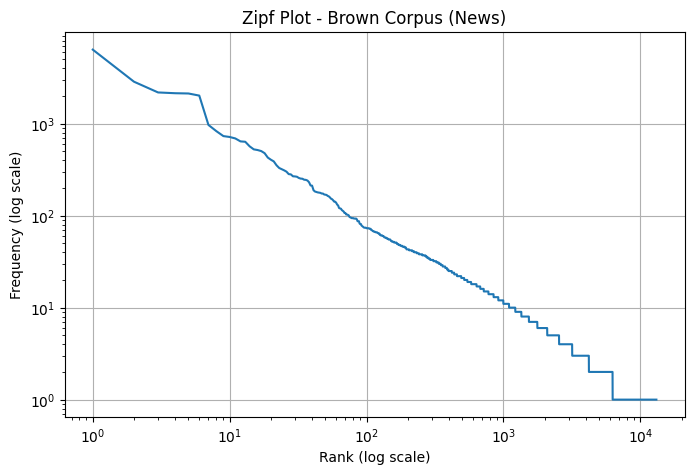

In [24]:
# Get ranked frequencies
frequencies = [freq for _, freq in fdist.most_common()]

plt.figure(figsize=(8,5))
plt.plot(range(1, len(frequencies) + 1), frequencies)
plt.xscale("log")
plt.yscale("log")

plt.title("Zipf Plot - Brown Corpus (News)")
plt.xlabel("Rank (log scale)")
plt.ylabel("Frequency (log scale)")
plt.grid(True)

plt.show()